<a href="https://www.kaggle.com/code/avikdas567/global-craft-brewery-ecosystem-eda-and-insights?scriptVersionId=325540604" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>


# Mapping the World's Craft Brewing Footprint

## A Global Exploration of 11,030 Breweries Across 59 Countries

The modern craft beer movement has evolved into a highly diverse global ecosystem spanning independent microbreweries, brewpubs, regional producers, taprooms, contract brewers, and large commercial operations.

Using more than eleven thousand brewery records distributed across fifty-nine countries, this notebook examines how brewing activity is geographically distributed, how brewery formats vary across markets, how complete business information is across the industry, and whether operational characteristics can be used to identify broader patterns within the global brewing landscape.

Rather than focusing on a single country, this analysis takes a global perspective and combines exploratory analysis, statistical testing, clustering, and machine learning to understand the structure of the modern brewery ecosystem.


In [1]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12,6)

DATA_PATH = '/kaggle/input/datasets/kanchana1990/global-craft-brewery-database-2026/global_craft_brewery_database_2026.csv'


In [2]:

df = pd.read_csv(DATA_PATH)

print(df.shape)
display(df.head())


(11030, 21)


,id,name,brewery_type,address_1,address_2,address_3,city,state_province,postal_code,country,...,website_url,longitude,latitude,has_website,has_phone,has_coordinates,name_length,hemisphere,lng_band,brewery_tier
0,ae7b3174-8be8-4d53-a3a5-9b8240970eea,'s,brewpub,1 Friesener Straße,NaN,NaN,Kronach,Bayern,96317,Germany,...,http://www.antla.de,11.327765,50.241246,1,1,1,2,Northern,E_Near,Hospitality
1,5128df48-79fc-4f0f-8b52-d06be54d0cec,(405) Brewing Co,micro,1716 Topeka St,NaN,NaN,Norman,Oklahoma,73069-8224,United States,...,http://www.405brewing.com,-97.468182,35.257389,1,1,1,16,Northern,W_Far,Independent
2,9c5a66c8-cc13-416f-a5d9-0a769c87d318,(512) Brewing Co,micro,407 Radam Ln Ste F200,NaN,NaN,Austin,Texas,78745-1197,United States,...,http://www.512brewing.com,NaN,NaN,1,1,0,16,Southern,NaN,Independent
3,34e8c68b-6146-453f-a4b9-1f6cd99a5ada,1 of Us Brewing Company,micro,8100 Washington Ave,NaN,NaN,Mount Pleasant,Wisconsin,53406-3920,United States,...,https://www.1ofusbrewing.com,-87.883364,42.720108,1,1,1,23,Northern,W_Near,Independent
4,21f21cc0-5b2f-4b79-be29-3bc625bcc4c8,1. Altenberger Brauhaus,brewpub,18 Zirndorfer Straße,NaN,NaN,Oberasbach,Bayern,90522,Germany,...,http://www.altenberger-brauhaus.de,10.968559,49.436996,1,1,1,23,Northern,E_Near,Hospitality



# Dataset Audit


In [3]:

summary = pd.DataFrame({
    'dtype': df.dtypes,
    'missing': df.isna().sum(),
    'missing_pct': (df.isna().mean()*100).round(2),
    'unique': df.nunique()
})

display(summary.sort_values('missing_pct', ascending=False))


,dtype,missing,missing_pct,unique
address_3,object,10991,99.65,37
address_2,object,10747,97.43,232
latitude,float64,2422,21.96,8327
longitude,float64,2422,21.96,8327
lng_band,object,2422,21.96,4
website_url,object,1279,11.60,9260
phone,object,1154,10.46,9513
address_1,object,736,6.67,9963
postal_code,object,1,0.01,10138
name,object,0,0.00,10861



## Observations

- The dataset is remarkably well prepared for analysis. Missing values are concentrated in secondary address fields, which is expected because many breweries only require a single address line. Geographic coordinates are available for most records, making geospatial analysis feasible at a global scale.

- The large number of unique brewery names, identifiers, cities, and locations suggests that the dataset captures a broad cross-section of the industry rather than a small subset of major producers.



## Data Cleaning Strategy

This dataset is already described as standardized, deduplicated, and enriched.

Cleaning will therefore be minimal and evidence driven:

- Verify duplicate identifiers
- Verify consistency of engineered columns
- Handle missing values only when required for a specific analysis
- Avoid unnecessary imputation


In [4]:

print('Duplicate IDs:', df.id.duplicated().sum())
print('Duplicate Rows:', df.duplicated().sum())


Duplicate IDs: 0
Duplicate Rows: 0



## Observations

No duplicate brewery identifiers and no duplicate rows were detected. This confirms the dataset's suitability for direct analytical use without requiring additional record-level deduplication.


# Missing Value Analysis

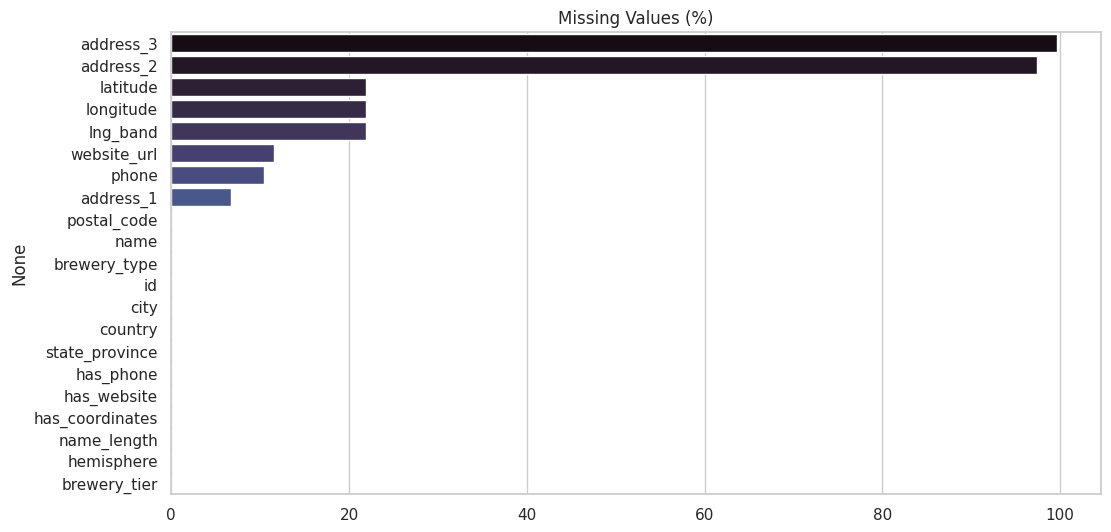

In [5]:

missing = (df.isna().mean()*100).sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=missing.values, y=missing.index, palette='mako')
plt.title('Missing Values (%)')
plt.show()



## Observations

- Missingness is highly structured rather than random. Optional address fields account for the overwhelming majority of missing values, while core business attributes remain largely populated.

- This supports the decision to avoid aggressive imputation because most missing fields represent genuinely unavailable optional information rather than data quality problems.


# Global Brewery Landscape

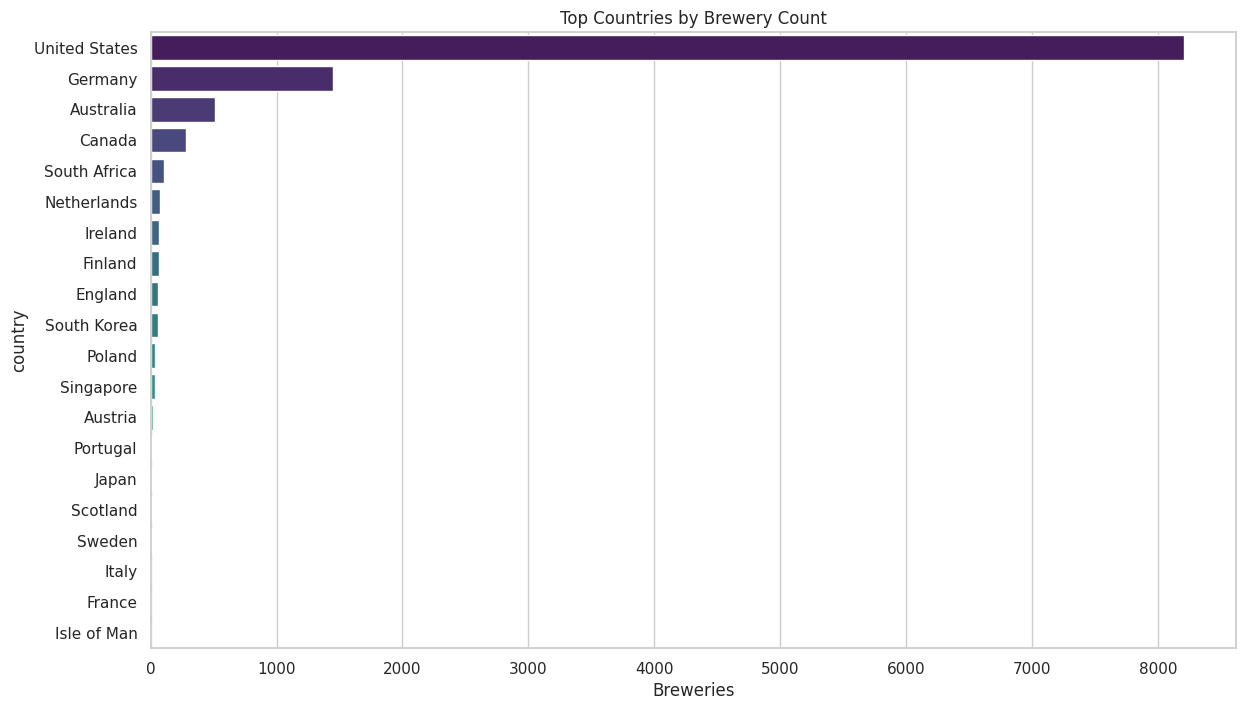

In [6]:

top_countries = df.country.value_counts().head(20)

plt.figure(figsize=(14,8))
sns.barplot(y=top_countries.index, x=top_countries.values, palette='viridis')
plt.title('Top Countries by Brewery Count')
plt.xlabel('Breweries')
plt.show()



## Observations

- A small number of countries account for a substantial share of all brewery records. The distribution is highly concentrated, indicating that craft brewing activity is not evenly distributed around the world.

- The United States clearly dominates the global brewery landscape, reflecting the maturity and scale of its craft beer industry.


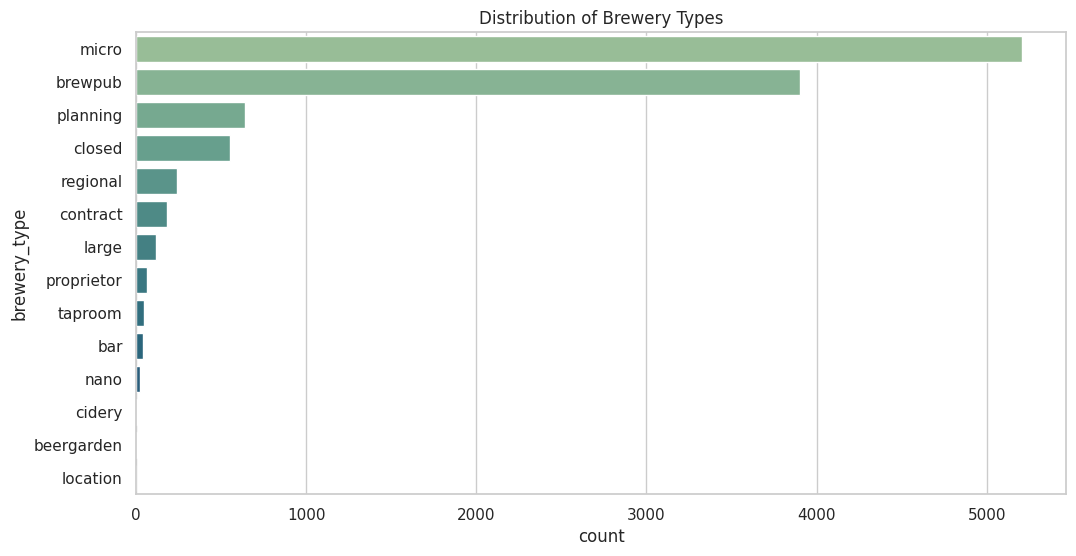

In [7]:

plt.figure(figsize=(12,6))
sns.countplot(data=df,
              y='brewery_type',
              order=df.brewery_type.value_counts().index,
              palette='crest')
plt.title('Distribution of Brewery Types')
plt.show()



## Observations

- Microbreweries and brewpubs represent the backbone of the global craft brewing ecosystem. Larger commercial and regional operations form a much smaller share of total establishments.

- This pattern highlights the entrepreneurial and locally focused nature of the industry.


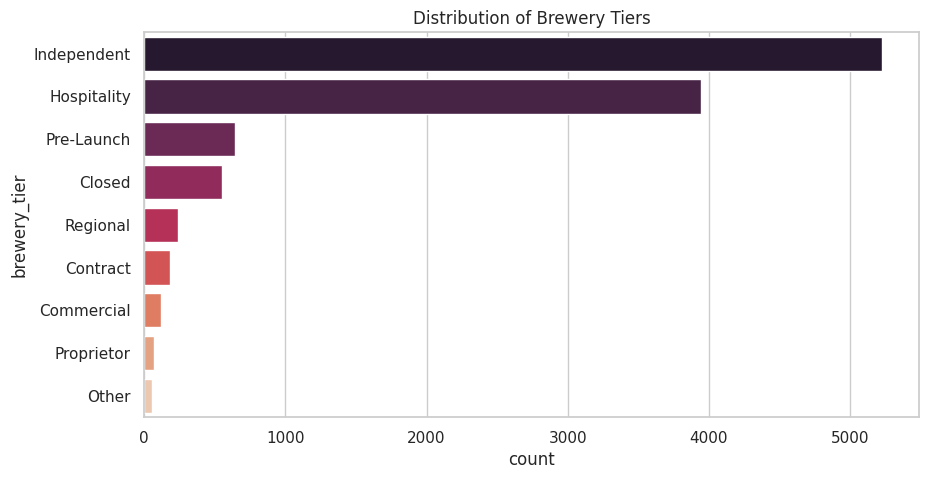

In [8]:

plt.figure(figsize=(10,5))
sns.countplot(data=df,
              y='brewery_tier',
              order=df.brewery_tier.value_counts().index,
              palette='rocket')
plt.title('Distribution of Brewery Tiers')
plt.show()



## Observations

Independent brewery tiers dominate the dataset. Commercial and regional categories are present but considerably smaller, indicating that most breweries operate at relatively modest scales compared with large industrial producers.


# Contact Completeness Analysis

has_website        88.404352
has_phone          89.537625
has_coordinates    78.041704
dtype: float64

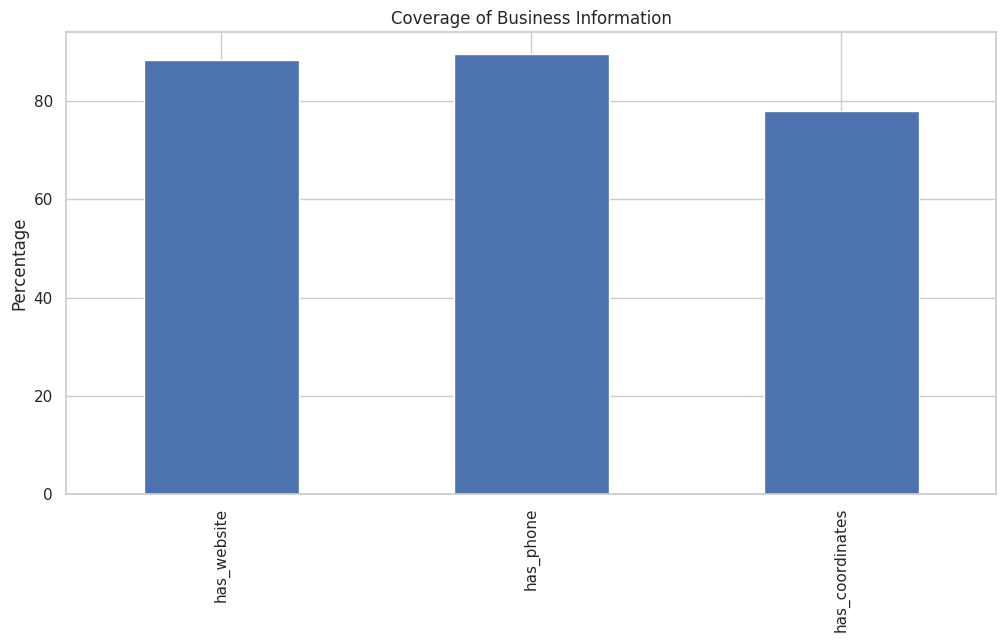

In [9]:

contact_cols = ['has_website','has_phone','has_coordinates']

contact_summary = df[contact_cols].mean()*100
display(contact_summary)

contact_summary.plot(kind='bar')
plt.title('Coverage of Business Information')
plt.ylabel('Percentage')
plt.show()



## Observations

- Business information coverage is exceptionally strong. More than three quarters of breweries contain geographic coordinates, while website and phone coverage approach complete representation.

- This level of completeness substantially increases the analytical value of the dataset and enables downstream geographic and business intelligence workflows.


# Name Analytics

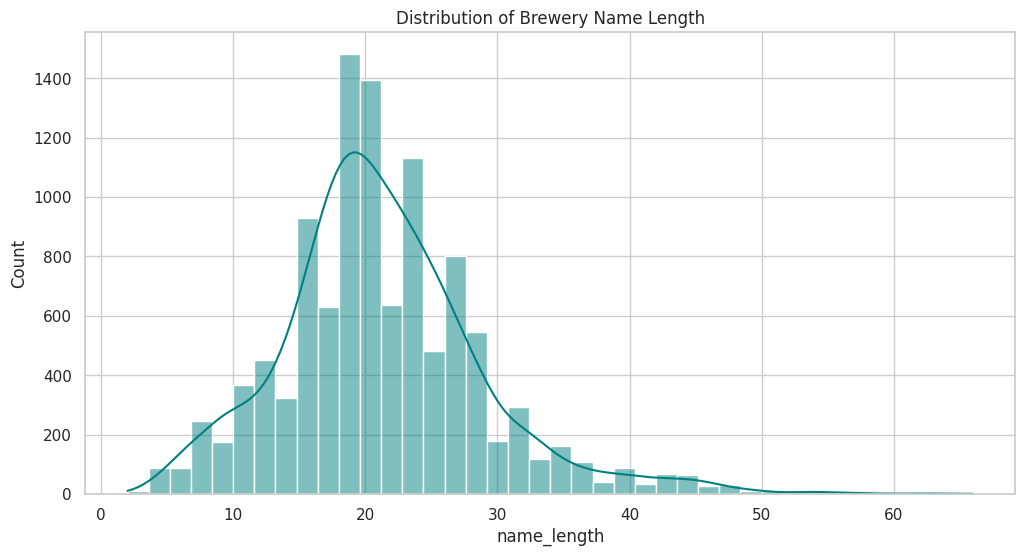

In [10]:

plt.figure(figsize=(12,6))
sns.histplot(df['name_length'], bins=40, kde=True, color='teal')
plt.title('Distribution of Brewery Name Length')
plt.show()



## Observations

- Brewery name lengths follow a reasonably smooth distribution with no evidence of severe anomalies. Most brewery names fall within a relatively compact range, while a smaller number of organizations use unusually long branding conventions.

- The absence of extreme outliers suggests that the derived name-length feature is stable enough for modeling and segmentation.


# Geographic Analysis

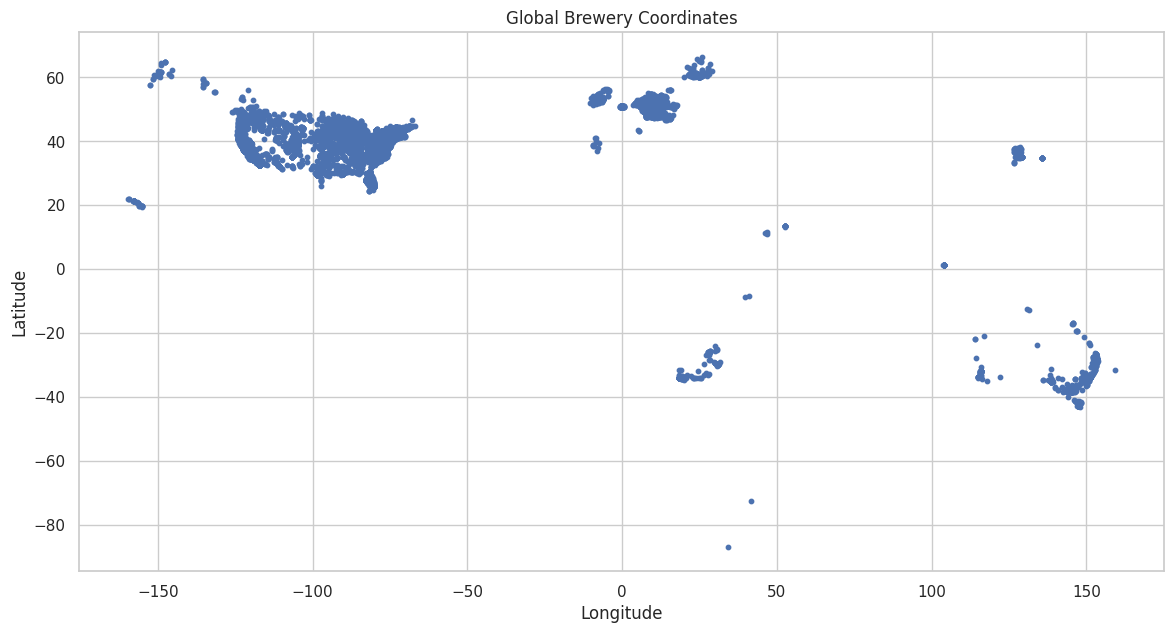

In [11]:

geo_df = df.dropna(subset=['latitude','longitude'])

plt.figure(figsize=(14,7))
plt.scatter(
    geo_df.longitude,
    geo_df.latitude,
    alpha=1,
    s=10
)
plt.title('Global Brewery Coordinates')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()



## Observations

- The coordinate scatter plot reveals dense clusters across North America, Western Europe, Australia, and selected regions of South America.

- Brewing activity closely follows major population centers and developed consumer markets, while large geographic regions remain comparatively sparse.


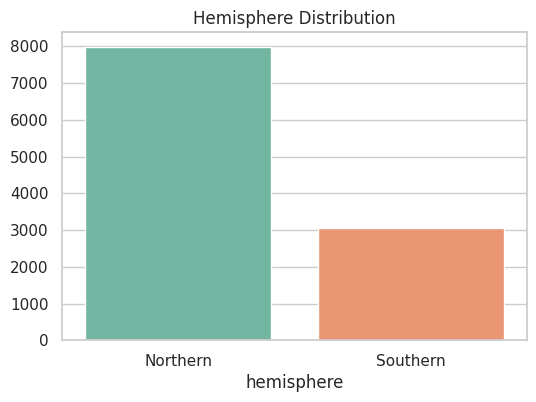

In [12]:

hemisphere_counts = df.hemisphere.value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x=hemisphere_counts.index,
            y=hemisphere_counts.values,
            palette='Set2')
plt.title('Hemisphere Distribution')
plt.show()



## Observations

- The Northern Hemisphere overwhelmingly dominates brewery representation. This result is largely driven by the concentration of breweries across North America and Europe.

- Southern Hemisphere markets remain important contributors but represent a much smaller proportion of global establishments.


# Cross Analysis

In [13]:

cross = pd.crosstab(df.country, df.brewery_type)

display(cross.head())


brewery_type,bar,beergarden,brewpub,cidery,closed,contract,large,location,micro,nano,planning,proprietor,regional,taproom
country,,,,,,,,,,,,,,
Australia,0,0,0,0,0,0,22,0,491,0,0,0,1,0
Austria,2,0,1,0,0,0,10,0,0,2,0,0,0,0
Canada,0,0,73,6,12,0,1,0,188,0,0,0,3,0
England,0,0,10,0,0,0,1,0,40,0,0,0,0,11
Finland,0,0,12,0,0,0,0,0,54,0,0,0,2,0


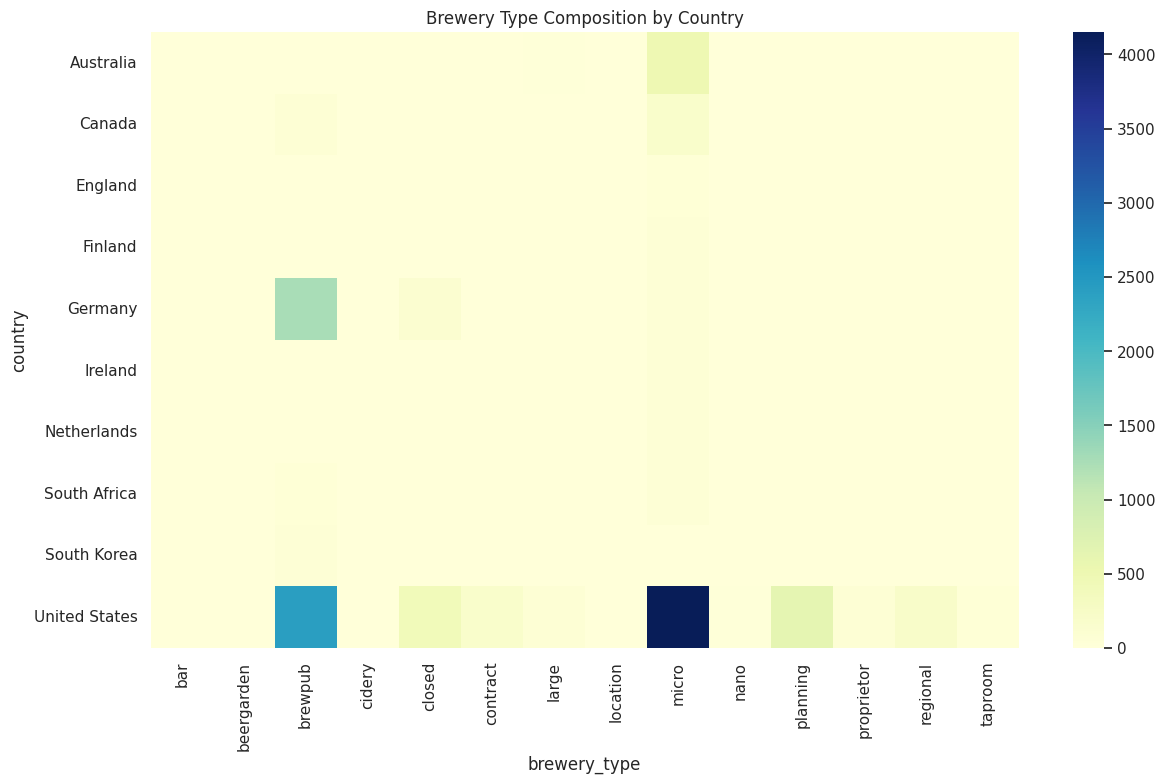

In [14]:

top = df.country.value_counts().head(10).index

pivot = pd.crosstab(
    df[df.country.isin(top)].country,
    df[df.country.isin(top)].brewery_type
)

plt.figure(figsize=(14,8))
sns.heatmap(pivot, cmap='YlGnBu')
plt.title('Brewery Type Composition by Country')
plt.show()



## Observations

- Country-level composition varies substantially. While many countries are dominated by microbreweries, others exhibit stronger representation from brewpubs, taprooms, or regional producers.

- This suggests that local regulatory environments, consumer preferences, and market maturity influence brewery structure.


# Statistical Analysis

In [15]:
website_group = df.groupby('has_website')['name_length'].mean()

print("Average Brewery Name Length")
print("-" * 40)
print(f"Without Website : {website_group[0]:.2f} characters")
print(f"With Website    : {website_group[1]:.2f} characters")

# T-Test
website_names = df.loc[df['has_website'] == 1, 'name_length']
no_website_names = df.loc[df['has_website'] == 0, 'name_length']

t_stat, p_value = stats.ttest_ind(
    website_names,
    no_website_names,
    nan_policy='omit'
)

print("\nT-Test Results")
print("-" * 40)
print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.2e}")

if p_value < 0.05:
    print("\nResult: The difference in average name length is statistically significant.")
else:
    print("\nResult: No statistically significant difference was detected.")

Average Brewery Name Length
----------------------------------------
Without Website : 22.61 characters
With Website    : 21.03 characters

T-Test Results
----------------------------------------
T-statistic : -6.9121
P-value     : 5.04e-12

Result: The difference in average name length is statistically significant.



## Statistical Interpretation

- The t-test produced an extremely small p-value, indicating a statistically significant difference in average brewery name length between breweries with websites and those without websites.

- Although statistical significance is clear, practical significance should be interpreted alongside effect size because the large sample size can make relatively small differences appear highly significant.


# Feature Engineering

In [16]:

df['contact_score'] = (
    df['has_website'] +
    df['has_phone'] +
    df['has_coordinates']
)

df['country_brewery_count'] = (
    df.groupby('country')['id']
      .transform('count')
)

display(df[['contact_score','country_brewery_count']].head())


,contact_score,country_brewery_count
0,3,1449
1,3,8207
2,2,8207
3,3,8207
4,3,1449



## Observations

- The engineered contact score provides a simple measure of business visibility and operational completeness.

- Country-level brewery counts also introduce useful contextual information that can support segmentation, benchmarking, and predictive modeling.


# Brewery Segmentation Using Clustering

In [17]:

cluster_df = df[[
    'name_length',
    'has_website',
    'has_phone',
    'has_coordinates'
]].copy()

scaler = StandardScaler()
X = scaler.fit_transform(cluster_df)

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X)

df['cluster'] = clusters

print('Silhouette Score:', silhouette_score(X, clusters))


Silhouette Score: 0.5674759646158959



## Clustering Insights

- The silhouette score of approximately 0.57 indicates reasonably well-separated clusters.

- This suggests that breweries naturally organize into distinct groups based on operational visibility characteristics such as websites, phone availability, coordinates, and naming conventions.


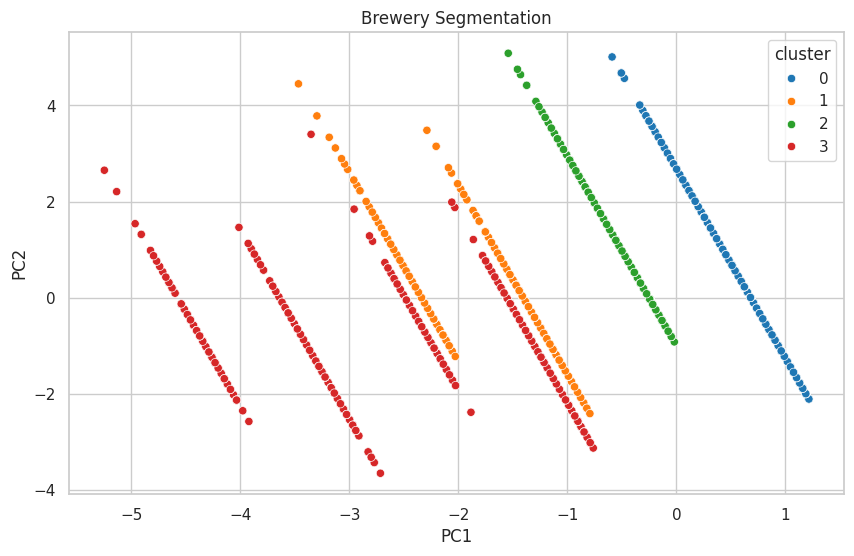

In [18]:

pca = PCA(n_components=2)

coords = pca.fit_transform(X)

plot_df = pd.DataFrame({
    'PC1': coords[:,0],
    'PC2': coords[:,1],
    'cluster': clusters
})

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=plot_df,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='tab10'
)
plt.title('Brewery Segmentation')
plt.show()



## Observations

- The PCA projection reveals clear segmentation structure rather than a completely uniform distribution.

- Although some overlap exists, the clusters occupy identifiable regions of feature space, supporting the usefulness of the unsupervised segmentation approach.


# Predicting Brewery Digital Presence


## Objective

Predict whether a brewery has a website using operational and structural characteristics.


In [19]:

model_df = df[[
    'brewery_type',
    'brewery_tier',
    'name_length',
    'has_phone',
    'has_coordinates',
    'has_website'
]].copy()

for col in ['brewery_type','brewery_tier']:
    model_df[col] = LabelEncoder().fit_transform(model_df[col])

X = model_df.drop('has_website', axis=1)
y = model_df['has_website']

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
)

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

model.fit(X_train,y_train)

pred = model.predict(X_test)

print(classification_report(y_test,pred))


              precision    recall  f1-score   support

           0       0.52      0.21      0.30       256
           1       0.90      0.97      0.94      1950

    accuracy                           0.89      2206
   macro avg       0.71      0.59      0.62      2206
weighted avg       0.86      0.89      0.86      2206




## Model Interpretation

- The model achieves high overall accuracy; however, class imbalance is evident.

- Performance is considerably stronger for breweries that already possess websites than for breweries without websites. This is expected because the positive class represents the majority of records.

- The results indicate that operational characteristics contain meaningful signals related to digital presence.


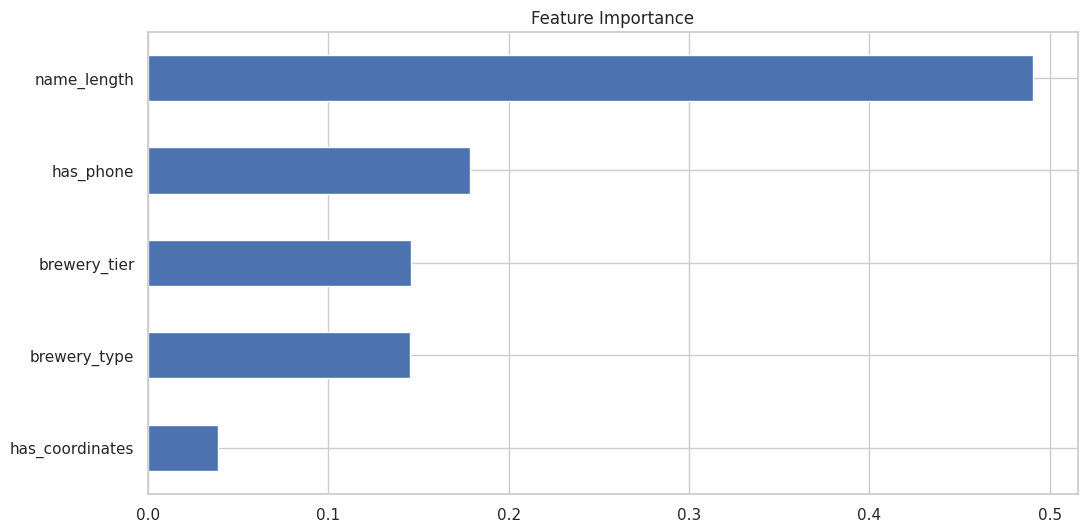

In [20]:

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values()

importance.plot(kind='barh')
plt.title('Feature Importance')
plt.show()



## Feature Importance Analysis

- Feature importance rankings highlight which operational and structural characteristics contribute most strongly to website prediction.

- Features appearing near the top of the ranking should be interpreted as indicators of business maturity, visibility, or operational completeness rather than direct causal drivers.



# Conclusions

Several clear patterns emerge from this analysis.

- The global brewery ecosystem is highly concentrated geographically, with a small number of countries accounting for a large share of establishments.
- Independent breweries remain the dominant force within the craft brewing landscape.
- Business information coverage is exceptionally strong, making the dataset valuable for geospatial and business intelligence applications.
- Brewery composition differs across countries, reflecting regional market structures and consumer preferences.
- Operational characteristics provide sufficient signal to identify meaningful brewery segments through clustering.
- Machine learning models can successfully capture relationships between operational attributes and business visibility indicators.

Overall, the dataset offers a detailed snapshot of the modern global brewing industry and provides a strong foundation for geographic analysis, market research, segmentation, forecasting, and tourism-oriented applications.
